# Importing all the libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# To store the plots
os.makedirs("plots", exist_ok=True)

# Loading both dataset

### historical_data

In [2]:
hist_data = pd.read_csv('./dataset/historical_data.csv')

### fear_greed_index

In [3]:
fear_greed = pd.read_csv('./dataset/fear_greed_index.csv')

## Understanding Data

### Checking shape of both datasets

In [4]:
print("Shape of historical data:", hist_data.shape)
print("Shape of fear_greed_index data:", fear_greed.shape)

Shape of historical data: (211224, 16)
Shape of fear_greed_index data: (2644, 4)


### Getting Overview of the data

In [5]:
hist_data.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [6]:
hist_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [7]:
fear_greed.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [8]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


#### Converting D-Types

In [9]:
hist_data["Timestamp IST"] = pd.to_datetime(hist_data["Timestamp IST"],format="%d-%m-%Y %H:%M")
hist_data["Timestamp"] = pd.to_datetime(hist_data["Timestamp"])

hist_data["date"] = hist_data["Timestamp IST"].dt.floor("D")

In [10]:
hist_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,2024-12-02


In [11]:
fear_greed["timestamp"] = pd.to_datetime(fear_greed["timestamp"])
fear_greed["date"] = pd.to_datetime(fear_greed["date"])

#### Seperating Categorical and Numerical Columns

In [12]:
# For other plotting purpose(not related)
# hist_data_cat_cols = ['Coin', 'Side', 'Direction', 'Crossed']
# hist_data_num_cols = ['Execution Price', 'Size Tokens', 'Size USD', 'Start Position', 'Closed PnL', 'Fee']

#### Checking Date&Time Columns

In [13]:
hist_data[['Timestamp IST', 'Timestamp', 'date']].head()

,Timestamp IST,Timestamp,date
0,2024-12-02 22:50:00,1970-01-01 00:28:50,2024-12-02
1,2024-12-02 22:50:00,1970-01-01 00:28:50,2024-12-02
2,2024-12-02 22:50:00,1970-01-01 00:28:50,2024-12-02
3,2024-12-02 22:50:00,1970-01-01 00:28:50,2024-12-02
4,2024-12-02 22:50:00,1970-01-01 00:28:50,2024-12-02


In [14]:
fear_greed[['timestamp', 'date']].head()

,timestamp,date
0,1970-01-01 00:00:01.517463000,2018-02-01
1,1970-01-01 00:00:01.517549400,2018-02-02
2,1970-01-01 00:00:01.517635800,2018-02-03
3,1970-01-01 00:00:01.517722200,2018-02-04
4,1970-01-01 00:00:01.517808600,2018-02-05


## Feature Engineering 
Aggregating trade-level data into daily metrics to analyze trader behavior under different market sentiment conditions.

The following features are created:

- Daily PnL: Total profit/loss per day
- Number of Trades: Total trades executed per day
- Average Trade Size: Mean trade size in USD
- Win Rate: Percentage of profitable trades per day
- Long/Short Ratio: Proportion of long positions
- Total Volume: Total traded volume per day

###### daily PnL per date, average trade size, total acc

In [15]:
daily_metrics = hist_data.groupby("date").agg({
    "Closed PnL": "sum",
    "Account": "count",
    "Size USD": "mean"
}).rename(columns={
    "Closed PnL": "daily_pnl",
    "Account": "num_trades",
    "Size USD": "avg_trade_size"
}).reset_index()

In [16]:
daily_metrics.head()

,date,daily_pnl,num_trades,avg_trade_size
0,2023-05-01,0.000000,3,159.000000
1,2023-12-05,0.000000,9,5556.203333
2,2023-12-14,-205.434737,11,10291.213636
3,2023-12-15,-24.632034,2,5304.975000
4,2023-12-16,0.000000,3,5116.256667


###### win rate

In [17]:
win_rate = hist_data.groupby("date")["Closed PnL"].apply(lambda x: (x > 0).mean())

daily_metrics["win_rate"] = daily_metrics["date"].map(win_rate)

In [18]:
daily_metrics.head()

,date,daily_pnl,num_trades,avg_trade_size,win_rate
0,2023-05-01,0.000000,3,159.000000,0.000000
1,2023-12-05,0.000000,9,5556.203333,0.000000
2,2023-12-14,-205.434737,11,10291.213636,0.363636
3,2023-12-15,-24.632034,2,5304.975000,0.000000
4,2023-12-16,0.000000,3,5116.256667,0.000000


###### long/short ratio

In [19]:
long_ratio = hist_data.groupby("date")["Direction"].apply(lambda x: (x == "Buy").mean())

daily_metrics["long_ratio"] = daily_metrics["date"].map(long_ratio)

In [20]:
sell_ratio = hist_data.groupby("date")["Direction"].apply(lambda x: (x == "Sell").mean())

daily_metrics["sell_ratio"] = daily_metrics["date"].map(sell_ratio)

In [21]:
# daily_metrics['long_ratio'].nunique()
daily_metrics['sell_ratio'].nunique()

185

###### total_volume

In [22]:
total_volume = hist_data.groupby("date")["Size USD"].sum()

daily_metrics["total_volume"] = daily_metrics["date"].map(total_volume)

In [23]:
daily_metrics.head()

,date,daily_pnl,num_trades,avg_trade_size,win_rate,long_ratio,sell_ratio,total_volume
0,2023-05-01,0.000000,3,159.000000,0.000000,0.0,0.0,477.00
1,2023-12-05,0.000000,9,5556.203333,0.000000,0.0,0.0,50005.83
2,2023-12-14,-205.434737,11,10291.213636,0.363636,0.0,0.0,113203.35
3,2023-12-15,-24.632034,2,5304.975000,0.000000,0.0,0.0,10609.95
4,2023-12-16,0.000000,3,5116.256667,0.000000,0.0,0.0,15348.77


###### mapping classification on fear_greed

In [24]:
# mapping
fear_greed["classification"] = fear_greed["classification"].str.strip().str.title()

mapping = {
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Neutral": "Neutral",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
}

fear_greed["classification"] = fear_greed["classification"].map(mapping)

In [25]:
fear_greed.head()

,timestamp,value,classification,date
0,1970-01-01 00:00:01.517463000,30,Fear,2018-02-01
1,1970-01-01 00:00:01.517549400,15,Fear,2018-02-02
2,1970-01-01 00:00:01.517635800,40,Fear,2018-02-03
3,1970-01-01 00:00:01.517722200,24,Fear,2018-02-04
4,1970-01-01 00:00:01.517808600,11,Fear,2018-02-05


### Merging Datasets

In [26]:
final_df = daily_metrics.merge(
    fear_greed[["date", "classification"]],
    on="date",
    how="left",
    validate="1:1"
)

In [27]:
final_df["classification"].isna().sum()

np.int64(1)

In [28]:
final_df.groupby("classification")[[
    "daily_pnl",
    "num_trades",
    "avg_trade_size",
    "win_rate",
    "long_ratio",
    "total_volume"
]].mean()

,daily_pnl,num_trades,avg_trade_size,win_rate,long_ratio,total_volume
classification,,,,,,
Fear,39012.054192,792.733333,6199.962861,0.328876,0.142749,5.693420e+06
Greed,15847.884637,294.120521,5872.025677,0.384793,0.051375,1.345432e+06
Neutral,19297.323516,562.477612,7157.527121,0.331886,0.119864,2.690180e+06


In [29]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            480 non-null    datetime64[ns]
 1   daily_pnl       480 non-null    float64       
 2   num_trades      480 non-null    int64         
 3   avg_trade_size  480 non-null    float64       
 4   win_rate        480 non-null    float64       
 5   long_ratio      480 non-null    float64       
 6   sell_ratio      480 non-null    float64       
 7   total_volume    480 non-null    float64       
 8   classification  479 non-null    object        
dtypes: datetime64[ns](1), float64(6), int64(1), object(1)
memory usage: 33.9+ KB


## Answering Questions

#### Q1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?

In [30]:
summary = final_df.groupby("classification", observed = True)[[
    "daily_pnl",
    "win_rate"
]].mean()

risk = final_df.groupby("classification", observed = True)["daily_pnl"].std()

print("Mean Performance:\n", summary)
print("\nPnL Volatility (Risk Proxy):\n", risk)

Mean Performance:
                    daily_pnl  win_rate
classification                        
Fear            39012.054192  0.328876
Greed           15847.884637  0.384793
Neutral         19297.323516  0.331886

PnL Volatility (Risk Proxy):
 classification
Fear       96894.941505
Greed      66645.098043
Neutral    37995.209071
Name: daily_pnl, dtype: float64


##### Fear days show much higher average PnL (39k) compared to Greed (15.8k), indicating higher profitability. However, Greed days have a higher win rate (~38.5% vs ~32.9%), meaning trades succeed more often. Volatility is highest during Fear, suggesting higher risk.

##### We can say that Fear markets generate larger profits per trade but with greater variability, while Greed markets provide more consistent but smaller gains.

#### Q2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [31]:
behavior = final_df.groupby("classification", observed=True)[[
    "num_trades",
    "avg_trade_size",
    "long_ratio",
    "total_volume"
]].mean()

behavior

,num_trades,avg_trade_size,long_ratio,total_volume
classification,,,,
Fear,792.733333,6199.962861,0.142749,5.693420e+06
Greed,294.120521,5872.025677,0.051375,1.345432e+06
Neutral,562.477612,7157.527121,0.119864,2.690180e+06


##### Yes, trader behavior changes based on sentiment.
##### Fear periods show the highest trading activity (~793 trades) and volume (~5.69M), compared to Greed (~294 trades, ~1.35M), indicating more aggressive participation.
##### Average trade size is slightly higher in Neutral (~7157) and Fear (~6200) than Greed (~5872), suggesting relatively higher risk-taking outside Greed.
##### Long ratio is lowest during Greed (~0.05 vs ~0.14 in Fear), indicating reduced buy-side bias.

##### In short, traders are more active during Fear, while Greed periods show lower activity and reduced directional exposure.

#### Q3.	Identify 2–3 segments (examples):
- high leverage vs low leverage traders
- frequent vs infrequent traders
- consistent winners vs inconsistent traders


##### Trading Activity V/S Profitability

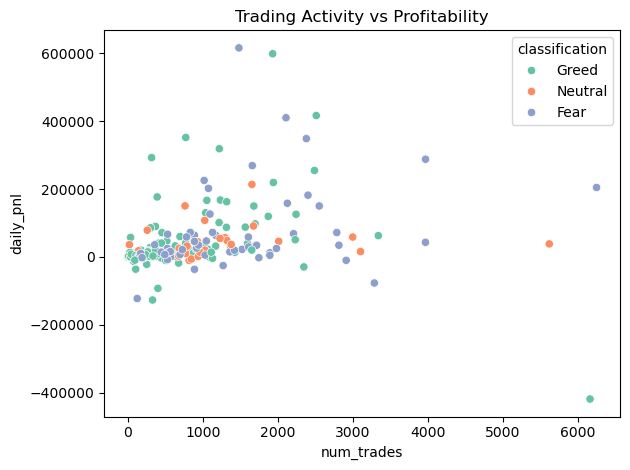

In [32]:
plt.figure()

sns.scatterplot(
    data=final_df,
    x="num_trades",
    y="daily_pnl",
    hue="classification",
    palette="Set2"
)

plt.title("Trading Activity vs Profitability")
plt.tight_layout()
plt.savefig("plots/trades_vs_pnl_scatter.png", dpi=180)
plt.show()

##### No of Trades V/S Win Rate

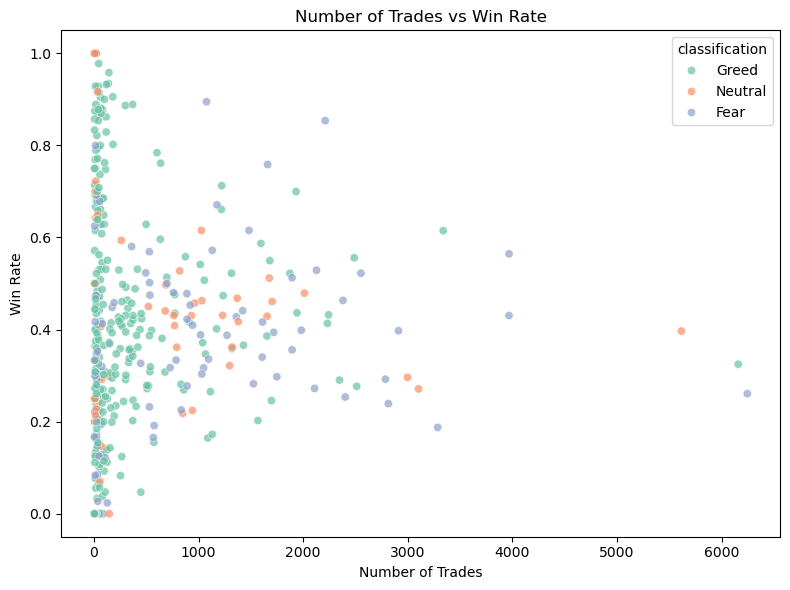

In [33]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=final_df,
    x="num_trades",
    y="win_rate",
    hue="classification",
    palette="Set2",
    alpha=0.7
)

plt.title("Number of Trades vs Win Rate")
plt.xlabel("Number of Trades")
plt.ylabel("Win Rate")

plt.tight_layout()
plt.savefig("plots/trades_vs_winrate.png", dpi=180)
plt.show()

##### Buy V/S Sell Ratio

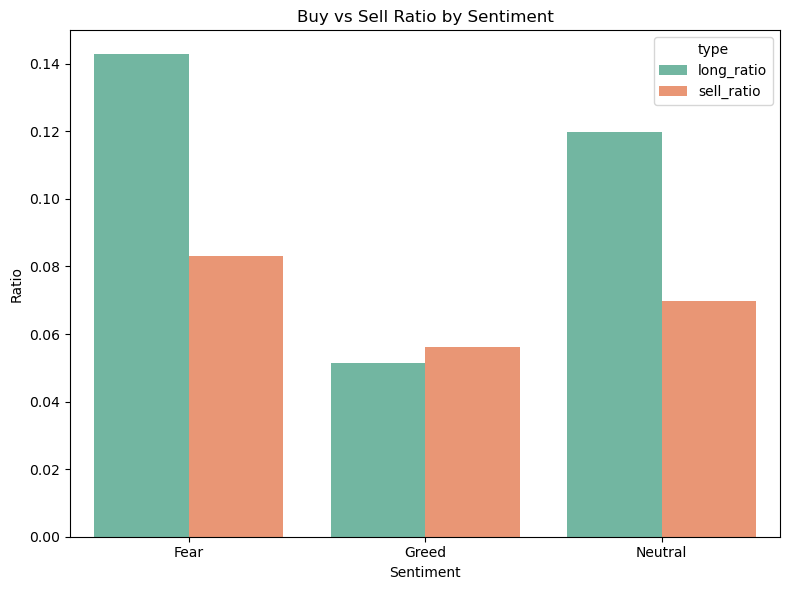

In [34]:
plt.figure(figsize=(8,6))

ratio_df = final_df.groupby("classification")[["long_ratio", "sell_ratio"]].mean().reset_index()

ratio_df_melt = ratio_df.melt(id_vars="classification", 
                             var_name="type", 
                             value_name="ratio")

sns.barplot(
    data=ratio_df_melt,
    x="classification",
    y="ratio",
    hue="type",
    palette="Set2"
)

plt.title("Buy vs Sell Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Ratio")

plt.tight_layout()
plt.savefig("plots/buy_sell_ratio_side.png", dpi=180)
plt.show()

#### Q4. Provide at least 3 insights backed by charts/tables

##### Insight 1. Average Daily PnL by Sentiment

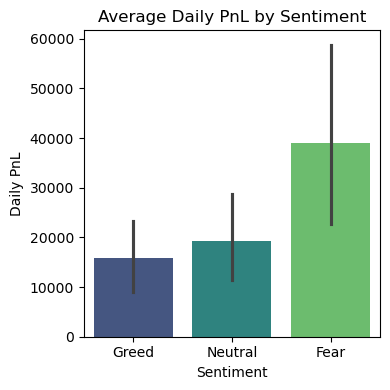

In [35]:
plt.figure(figsize=(4,4))

sns.barplot(
    data=final_df,
    x="classification",
    y="daily_pnl",
    estimator=np.mean,
    hue="classification",
    palette="viridis",
    legend=False
)

plt.title("Average Daily PnL by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Daily PnL")

plt.tight_layout()
plt.savefig("plots/insight1_pnl.png", dpi=180)
plt.show()

###### From the table and chart, Fear days have much higher average PnL (~39k) compared to Greed (~15k).
###### Even though Greed has higher win rate, the total profit is lower.
###### This shows that traders make bigger profits during Fear periods.

##### Insight 2. Trading Activity vs Profit

                num_trades  total_volume
classification                          
Fear            792.733333  5.693420e+06
Greed           294.120521  1.345432e+06
Neutral         562.477612  2.690180e+06


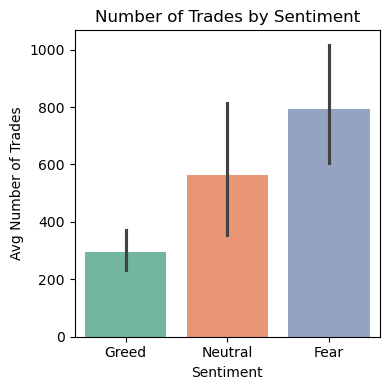

In [36]:
activity_summary = final_df.groupby("classification")[["num_trades", "total_volume"]].mean()
print(activity_summary)

plt.figure(figsize=(4,4))

sns.barplot(
    data=final_df,
    x="classification",
    y="num_trades",
    estimator=np.mean,
    hue="classification",
    palette="Set2",
    legend=False
)

plt.title("Number of Trades by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Avg Number of Trades")

plt.tight_layout()
plt.savefig("plots/insight2_trades.png", dpi=180)
plt.show()

###### Fear days have the highest number of trades (~793) and volume, while Greed has much lower activity (~294 trades).
###### This suggests that traders are more active during Fear, possibly due to panic or more opportunities.

##### Insight 3. Buy vs Sell Behavior

                long_ratio  sell_ratio
classification                        
Fear              0.142749    0.083161
Greed             0.051375    0.056067
Neutral           0.119864    0.069695


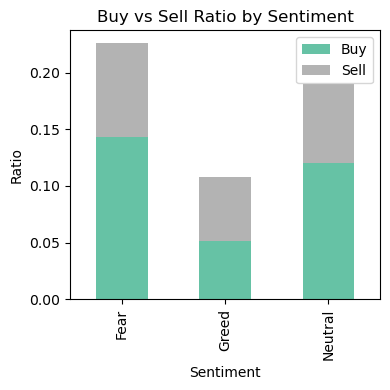

In [37]:
# Table
ratio_table = final_df.groupby("classification")[["long_ratio", "sell_ratio"]].mean()
print(ratio_table)

# Plot
ratio_table.plot(kind="bar", stacked=True, figsize=(4,4), colormap="Set2")

plt.title("Buy vs Sell Ratio by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Ratio")

plt.legend(["Buy", "Sell"])
plt.tight_layout()
plt.savefig("plots/insight3_buy_sell.png", dpi=180)
plt.show()

###### Buy (long) ratio is lowest during Greed (~0.05) compared to Fear (~0.14).
###### This is unexpected because Greed usually means bullish behavior.
###### It suggests that traders might be selling or booking profits during Greed periods.

# Actionable Output

#### Strategy

##### 1. During Fear periods, traders can focus on fewer but higher conviction trades instead of overtrading. Since Fear shows higher overall profits but also higher volatility, it’s better to manage risk (smaller position size or controlled exposure) while taking advantage of larger price moves.

##### 2. During Greed periods, traders should avoid overconfidence and not rely only on high win rates. Even though trades succeed more often, overall profits are lower, so focusing on better risk-reward trades (instead of many small wins) can improve performance.